In [117]:
! pip install xgboost scikit-learn scikit-optimize matplotlib seaborn pandas numpy joblib tqdm imblearn


   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-l


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [118]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from tqdm.auto import tqdm
from sklearn.metrics import precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


warnings.filterwarnings('ignore')

## Import Data

In [119]:
clinical_data = pd.read_csv('F:/cirrhosis+patient+survival+prediction+dataset-1/clinical_data_processed.csv')

In [120]:
clinical_data.head(50)

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,...,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Ascites_missing,Hepatomegaly_missing,Spiders_missing
0,16.027556,3,1,124.941528,1,2,2,2,3,103.014440,...,52.794521,21.950609,52.539568,49.957522,51.842315,4.2,4.0,0,0,0
1,187.651451,1,1,116.094531,1,1,2,2,1,6.747292,...,18.037671,105.178334,41.257206,20.371681,64.155689,2.6,3.0,0,0,0
2,41.645562,3,1,168.079782,2,1,1,1,2,8.902527,...,71.195205,4.328053,33.212230,8.748673,36.351297,4.0,4.0,0,0,0
3,79.863273,3,1,109.587235,1,1,2,2,2,11.776173,...,21.445205,86.514845,16.831330,21.780531,49.061876,2.3,4.0,0,0,0
4,62.240429,2,3,46.122822,1,1,2,2,1,23.270758,...,48.364726,6.600513,41.086331,14.736283,30.393214,2.9,3.0,0,0,0
5,104.058056,3,3,153.529761,1,1,2,1,1,4.592058,...,16.674658,10.602973,31.780576,11.566372,71.702595,3.0,3.0,0,0,0
6,75.970341,1,3,112.616313,1,1,2,1,1,6.028881,...,17.356164,8.843650,16.748201,64.398230,57.403194,1.7,3.0,0,0,0
7,102.509255,3,3,103.163500,1,1,1,1,1,1.000000,...,17.356164,64.954337,1.937503,55.945133,124.530938,3.0,3.0,0,0,0
8,99.746529,3,1,62.918539,1,1,1,2,1,21.833935,...,26.556507,30.131463,55.402878,20.371681,76.071856,3.0,2.0,0,0,0
9,1.418595,3,3,169.939009,1,2,1,2,3,89.364621,...,47.342466,10.221787,56.834532,39.743363,96.329341,3.5,4.0,0,0,0


In [121]:
# print the data types of each column
print(clinical_data.dtypes)

N_Days                  float64
Status                    int64
Drug                      int64
Age                     float64
Sex                       int64
Ascites                   int64
Hepatomegaly              int64
Spiders                   int64
Edema                     int64
Bilirubin               float64
Cholesterol             float64
Albumin                 float64
Copper                  float64
Alk_Phos                float64
SGOT                    float64
Tryglicerides           float64
Platelets               float64
Prothrombin             float64
Stage                   float64
Ascites_missing           int64
Hepatomegaly_missing      int64
Spiders_missing           int64
dtype: object


## Data Exploration

In [122]:
# Check data shape and basic info
print(f"Dataset shape: {clinical_data.shape}")
print(f"\nMissing values:\n{clinical_data.isnull().sum()}")
print(f"\nClass distribution:\n{clinical_data['Stage'].value_counts().sort_index()}")

Dataset shape: (412, 22)

Missing values:
N_Days                  0
Status                  0
Drug                    0
Age                     0
Sex                     0
Ascites                 0
Hepatomegaly            0
Spiders                 0
Edema                   0
Bilirubin               0
Cholesterol             0
Albumin                 0
Copper                  0
Alk_Phos                0
SGOT                    0
Tryglicerides           0
Platelets               0
Prothrombin             0
Stage                   0
Ascites_missing         0
Hepatomegaly_missing    0
Spiders_missing         0
dtype: int64

Class distribution:
Stage
1.0     21
2.0     92
3.0    155
4.0    144
Name: count, dtype: int64


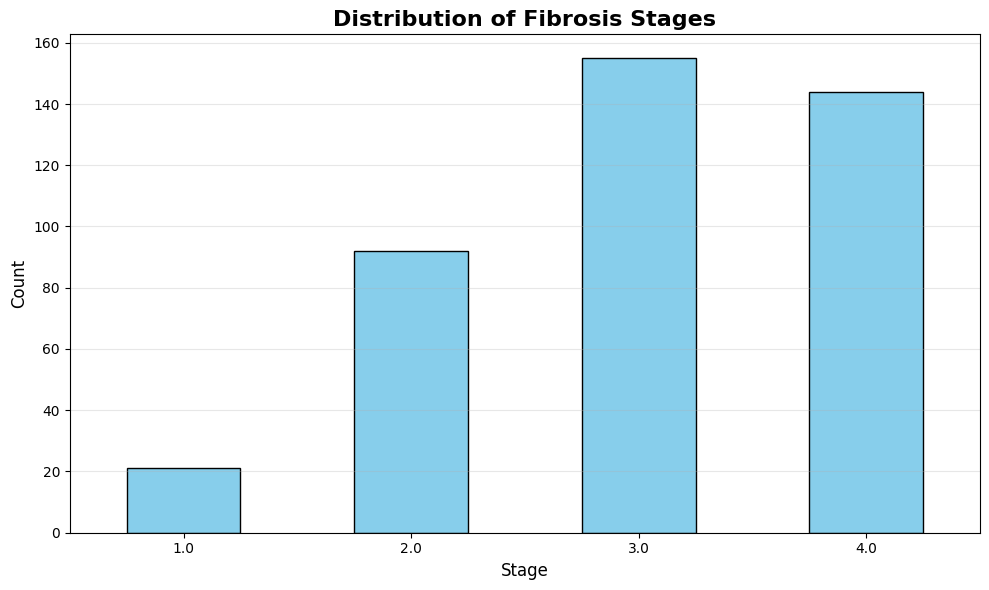

In [123]:
# Visualize class distribution
plt.figure(figsize=(10, 6))
clinical_data['Stage'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Fibrosis Stages', fontsize=16, fontweight='bold')
plt.xlabel('Stage', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Prepare Data for Training

In [124]:
# Separate features and target
X = clinical_data.drop('Stage', axis=1)
y = clinical_data['Stage']

# Convert target to 0-based indexing for XGBoost 
# 1.0->0, 2.0->1, 3.0->2, 4.0->3
y = y - 1

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target classes: {sorted(y.unique())}")

Features shape: (412, 21)
Target shape: (412,)
Target classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


In [125]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_res, y_train_res = SMOTE().fit_resample(X_train, y_train)
X_train = X_train_res
y_train = y_train_res

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest set class distribution:\n{y_test.value_counts().sort_index()}")

Training set size: 496
Test set size: 83

Training set class distribution:
Stage
0.0    124
1.0    124
2.0    124
3.0    124
Name: count, dtype: int64

Test set class distribution:
Stage
0.0     4
1.0    19
2.0    31
3.0    29
Name: count, dtype: int64


## Bayesian Optimization for Hyperparameter Tuning

In [126]:
# Define the parameter search space for Bayesian Optimization
param_space = {
    'max_depth': Integer(3, 12),
    'learning_rate': Real(0.005, 0.3, prior='log-uniform'),
    'n_estimators': Integer(100, 1200),
    'min_child_weight': Integer(1, 15),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'gamma': Real(0, 10),
    'reg_alpha': Real(0, 30),
    'reg_lambda': Real(0, 30),
}


# Initialize XGBoost with early stopping
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    tree_method='hist',
    device='cuda',
    random_state=42,
    eval_metric='mlogloss',
    n_estimators=200            
)

print("Starting Bayesian Optimization...")

Starting Bayesian Optimization...


In [127]:
# Create a custom callback with progress bar
class TqdmCallback:
    def __init__(self, n_iter):
        self.pbar = tqdm(total=n_iter, desc="Bayesian Optimization")
        
    def __call__(self, res):
        self.pbar.update(1)
        # Update description with current best score
        if hasattr(res, 'fun'):
            self.pbar.set_postfix({'Best Score': f'{-res.fun:.4f}'})
    
    def close(self):
        self.pbar.close()

# Perform Bayesian Optimization with progress bar
callback = TqdmCallback(n_iter=50)

Bayesian Optimization:   0%|          | 0/50 [00:00<?, ?it/s]

In [128]:
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_space,
    n_iter=100, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=1,
    verbose=0,
    random_state=42
)

# Fit with callback
try:
    bayes_search.fit(X_train, y_train, callback=callback)
finally:
    callback.close()

print("\n" + "="*80)
print("Bayesian Optimization Complete!")
print("="*80)
print(f"\nBest parameters found: {bayes_search.best_params_}")
print(f"Best cross-validation F1 score: {bayes_search.best_score_:.4f}")

Bayesian Optimization: 100it [29:59, 17.99s/it, Best Score=0.6889]                       


Bayesian Optimization Complete!

Best parameters found: OrderedDict([('colsample_bytree', 0.6752560504818483), ('gamma', 0.0), ('learning_rate', 0.03253865582843669), ('max_depth', 12), ('min_child_weight', 1), ('n_estimators', 1200), ('reg_alpha', 0.0), ('reg_lambda', 16.75835130645958), ('subsample', 1.0)])
Best cross-validation F1 score: 0.6889


In [129]:
# Get the best model from Bayesian Search
best_model = bayes_search.best_estimator_

print("Best model obtained from Bayesian Optimization")
print(f"Model parameters: {best_model.get_params()}")

Best model obtained from Bayesian Optimization
Model parameters: {'objective': 'multi:softmax', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.6752560504818483, 'device': 'cuda', 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'mlogloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.0, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.03253865582843669, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 12, 'max_leaves': None, 'min_child_weight': 1, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 16.75835130645958, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 1.0, 'tree_method': 'hist', 'validate_paramete

## Model Evaluation

In [130]:
# Make predictions on train and test sets
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.4578


In [131]:
# Classification report for test set
print("\n" + "="*80)
print("CLASSIFICATION REPORT - TEST SET")
print("="*80)
class_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
print(classification_report(y_test, y_test_pred, target_names=class_names, digits=4))


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

     Stage 1     0.0000    0.0000    0.0000         4
     Stage 2     0.3125    0.2632    0.2857        19
     Stage 3     0.4211    0.5161    0.4638        31
     Stage 4     0.7083    0.5862    0.6415        29

    accuracy                         0.4578        83
   macro avg     0.3605    0.3414    0.3477        83
weighted avg     0.4763    0.4578    0.4628        83



In [132]:
# Calculate per-class metrics
print("\n" + "="*80)
print("PER-CLASS METRICS - TEST SET")
print("="*80)

for i, stage in enumerate(class_names):
    precision = precision_score(y_test, y_test_pred, labels=[i], average='macro', zero_division=0)
    recall = recall_score(y_test, y_test_pred, labels=[i], average='macro', zero_division=0)
    f1 = f1_score(y_test, y_test_pred, labels=[i], average='macro', zero_division=0)
    
    print(f"\n{stage}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# Overall metrics
print(f"\n{'='*80}")
print("OVERALL METRICS")
print("="*80)
print(f"Weighted Precision: {precision_score(y_test, y_test_pred, average='weighted', zero_division=0):.4f}")
print(f"Weighted Recall:    {recall_score(y_test, y_test_pred, average='weighted', zero_division=0):.4f}")
print(f"Weighted F1-Score:  {f1_score(y_test, y_test_pred, average='weighted', zero_division=0):.4f}")
print(f"Macro Precision:    {precision_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:       {recall_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:     {f1_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")


PER-CLASS METRICS - TEST SET

Stage 1:
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Stage 2:
  Precision: 0.3125
  Recall:    0.2632
  F1-Score:  0.2857

Stage 3:
  Precision: 0.4211
  Recall:    0.5161
  F1-Score:  0.4638

Stage 4:
  Precision: 0.7083
  Recall:    0.5862
  F1-Score:  0.6415

OVERALL METRICS
Weighted Precision: 0.4763
Weighted Recall:    0.4578
Weighted F1-Score:  0.4628
Macro Precision:    0.3605
Macro Recall:       0.3414
Macro F1-Score:     0.3477


## Visualizations

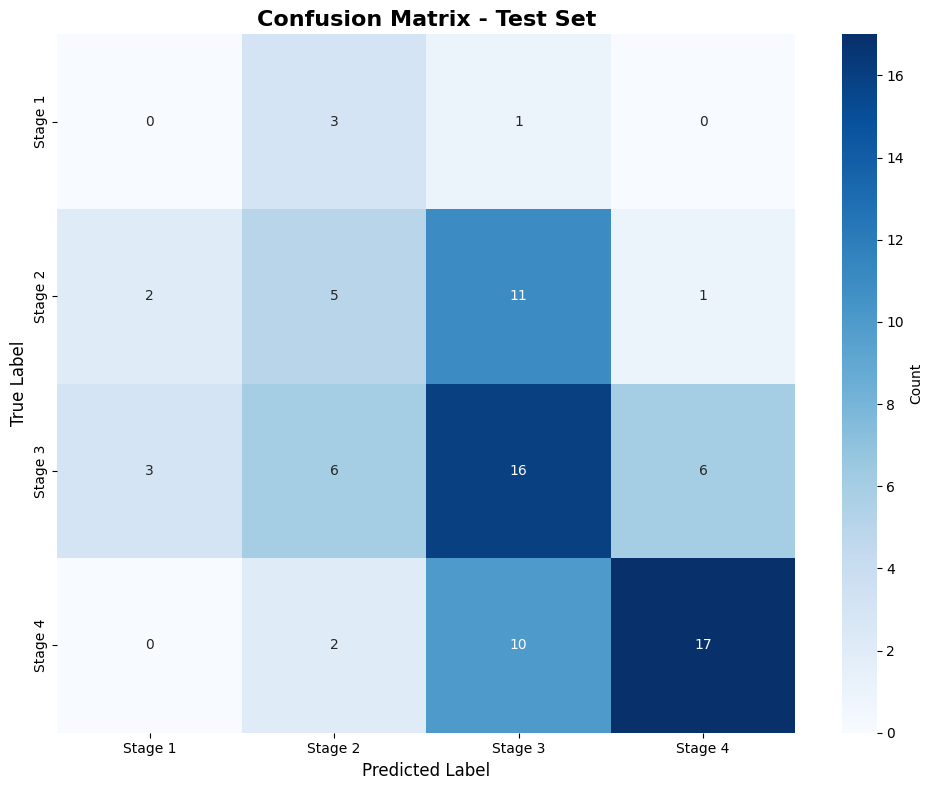

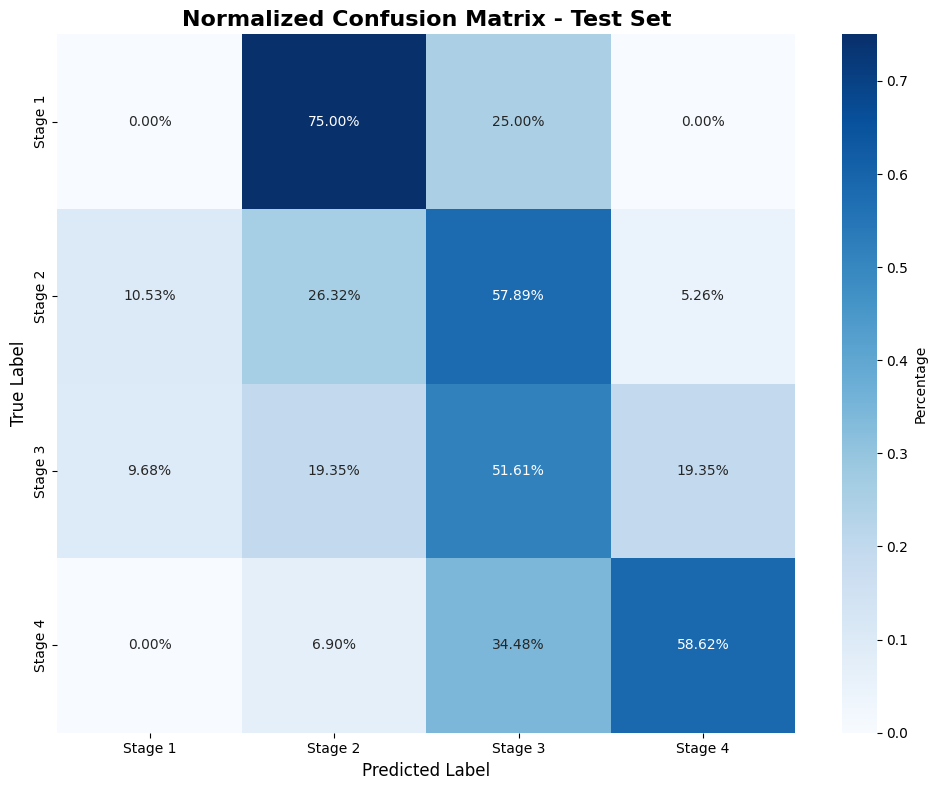

In [133]:
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Normalized Confusion Matrix
plt.figure(figsize=(10, 8))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

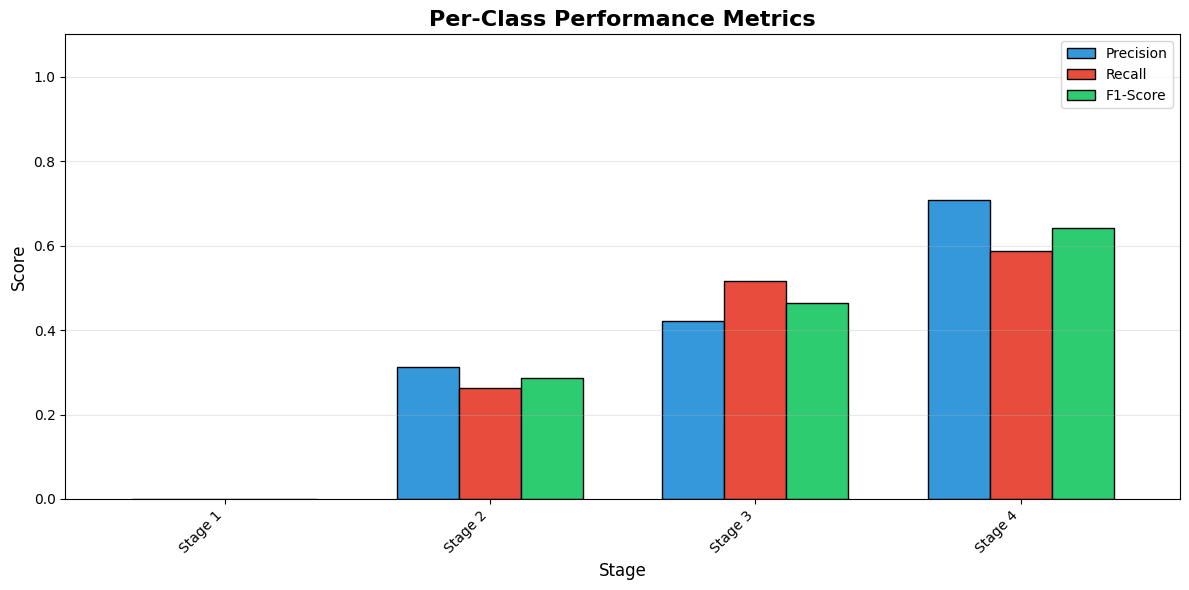


Per-Class Metrics Table:
         Precision  Recall  F1-Score
Stage 1     0.0000  0.0000    0.0000
Stage 2     0.3125  0.2632    0.2857
Stage 3     0.4211  0.5161    0.4638
Stage 4     0.7083  0.5862    0.6415


In [134]:
# Per-class metrics visualization
# Calculate precision, recall, and F1 for each class individually
# Get per-class metrics
precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_test, y_test_pred, labels=[0, 1, 2, 3], average=None, zero_division=0
)

metrics_df = pd.DataFrame({
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class
}, index=class_names)

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', width=0.7)
plt.title('Per-Class Performance Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Stage', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display the metrics table
print("\nPer-Class Metrics Table:")
print(metrics_df.round(4))

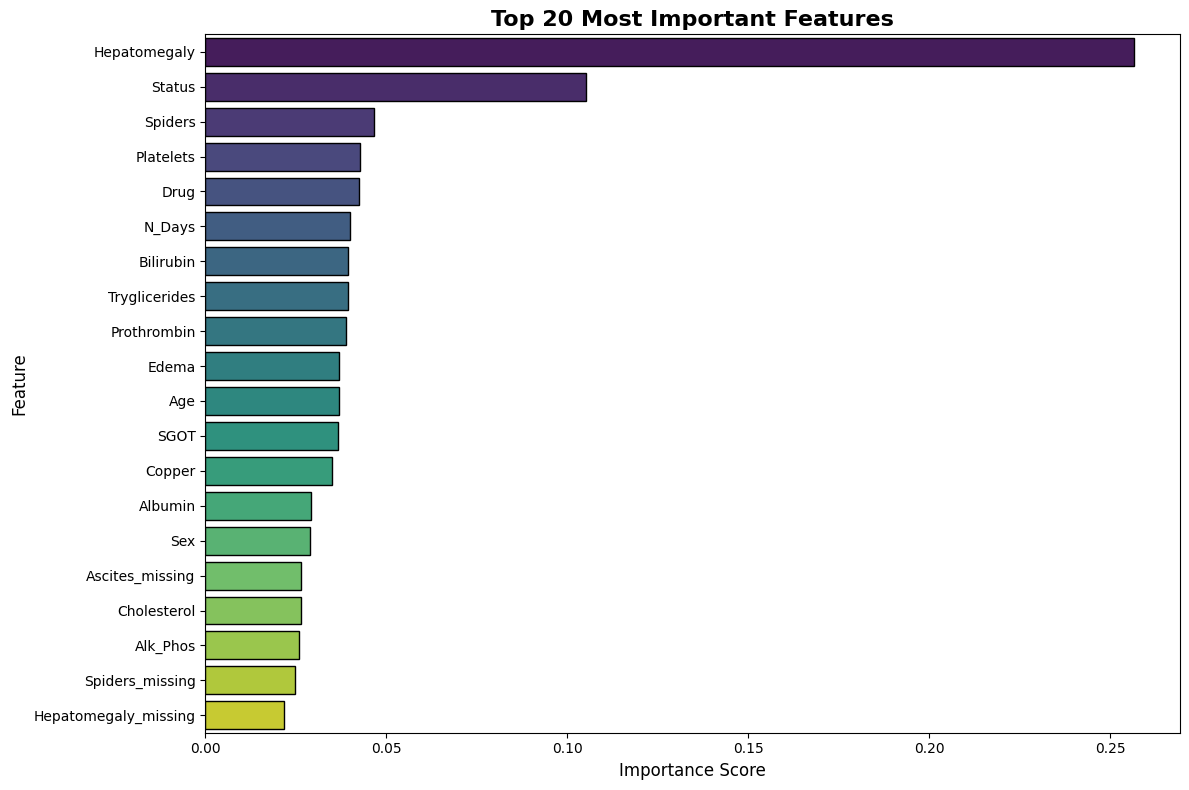


Top 10 Most Important Features:
      Feature  Importance
 Hepatomegaly    0.256433
       Status    0.105244
      Spiders    0.046625
    Platelets    0.042691
         Drug    0.042533
       N_Days    0.039819
    Bilirubin    0.039387
Tryglicerides    0.039285
  Prothrombin    0.038781
        Edema    0.036885


In [135]:
# Feature importance plot
feature_importance = best_model.feature_importances_
feature_names = X.columns

# Create a dataframe for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_n = min(20, len(importance_df))
sns.barplot(data=importance_df.head(top_n), x='Importance', y='Feature', palette='viridis', edgecolor='black')
plt.title(f'Top {top_n} Most Important Features', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

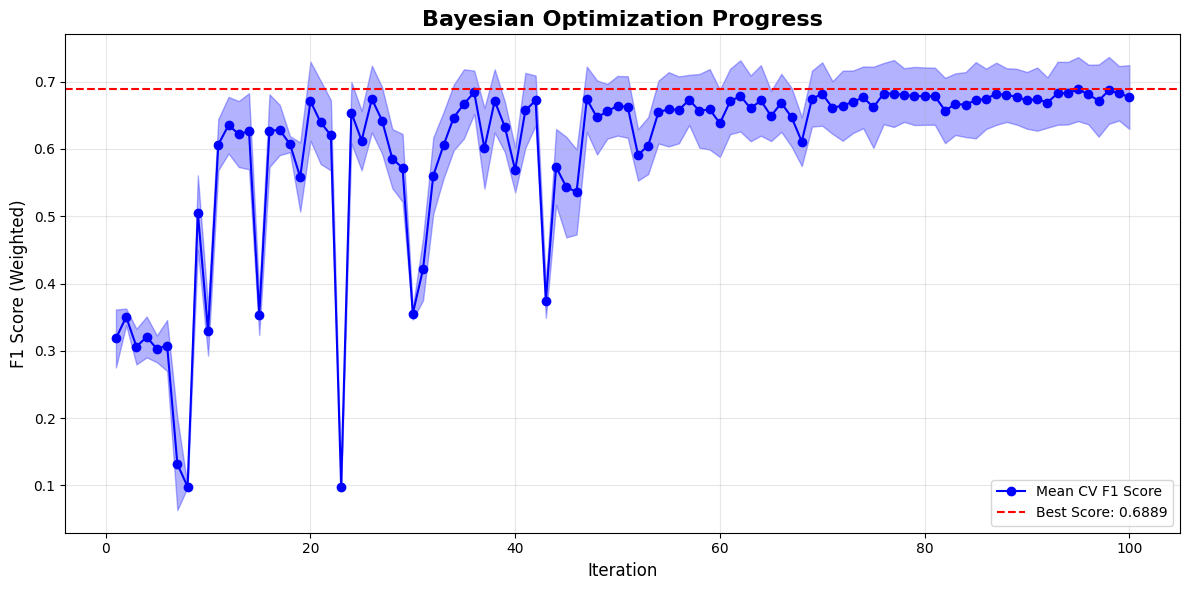

In [136]:
# Learning curve - model performance during Bayesian optimization
cv_results = pd.DataFrame(bayes_search.cv_results_)
cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False)

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cv_results) + 1), cv_results['mean_test_score'], marker='o', linestyle='-', color='blue', label='Mean CV F1 Score')
plt.fill_between(range(1, len(cv_results) + 1), 
                 cv_results['mean_test_score'] - cv_results['std_test_score'],
                 cv_results['mean_test_score'] + cv_results['std_test_score'],
                 alpha=0.3, color='blue')
plt.axhline(y=bayes_search.best_score_, color='r', linestyle='--', label=f'Best Score: {bayes_search.best_score_:.4f}')
plt.title('Bayesian Optimization Progress', fontsize=16, fontweight='bold')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('F1 Score (Weighted)', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Model Export

In [137]:
# import os

# # Create output directory if it doesn't exist
# output_dir = '../../Models/Clinical_Data/XGBoost'
# os.makedirs(output_dir, exist_ok=True)

# # Save the best model using joblib
# model_path = os.path.join(output_dir, 'xgboost_clinical_model.pkl')
# joblib.dump(best_model, model_path)
# print(f"Model saved to: {model_path}")

# # Save the model using XGBoost native format
# xgb_model_path = os.path.join(output_dir, 'xgboost_clinical_model.json')
# best_model.save_model(xgb_model_path)
# print(f"XGBoost model saved to: {xgb_model_path}")

# # Save feature names for later use
# feature_names_path = os.path.join(output_dir, 'feature_names.pkl')
# joblib.dump(list(X.columns), feature_names_path)
# print(f"Feature names saved to: {feature_names_path}")

# # Save best parameters
# import json
# best_params_path = os.path.join(output_dir, 'best_parameters.json')
# with open(best_params_path, 'w') as f:
#     json.dump(bayes_search.best_params_, f, indent=4)
# print(f"Best parameters saved to: {best_params_path}")

# # Save model performance metrics
# metrics_dict = {
#     'test_accuracy': float(test_accuracy),
#     'train_accuracy': float(train_accuracy),
#     'weighted_precision': float(precision_score(y_test, y_test_pred, average='weighted', zero_division=0)),
#     'weighted_recall': float(recall_score(y_test, y_test_pred, average='weighted', zero_division=0)),
#     'weighted_f1': float(f1_score(y_test, y_test_pred, average='weighted', zero_division=0)),
#     'macro_precision': float(precision_score(y_test, y_test_pred, average='macro', zero_division=0)),
#     'macro_recall': float(recall_score(y_test, y_test_pred, average='macro', zero_division=0)),
#     'macro_f1': float(f1_score(y_test, y_test_pred, average='macro', zero_division=0)),
#     'per_class_metrics': {
#         class_names[i]: {
#             'precision': float(precision_score(y_test, y_test_pred, labels=[i], average='binary', zero_division=0)),
#             'recall': float(recall_score(y_test, y_test_pred, labels=[i], average='binary', zero_division=0)),
#             'f1_score': float(f1_score(y_test, y_test_pred, labels=[i], average='binary', zero_division=0))
#         } for i in range(4)
#     }
# }

# metrics_path = os.path.join(output_dir, 'model_metrics.json')
# with open(metrics_path, 'w') as f:
#     json.dump(metrics_dict, f, indent=4)
# print(f"Model metrics saved to: {metrics_path}")

# print("\n" + "="*80)
# print("All model artifacts saved successfully!")
# print("="*80)